Use this notebook to orchestrate a single model fit, simulate from the fitted parameters, and generate benchmark diagnostics.

In [1]:
# import jax
# jax.config.update("jax_disable_jit", True)
# jax.config.update("jax_debug_nans", True)

import inspect
import json
import os
import warnings
from pathlib import Path
from typing import Any, Mapping, Sequence, cast, Type

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import papermill as pm
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
)
from jaxcmr.simulation import simulate_h5_from_h5
from jaxcmr.summarize import summarize_parameters

warnings.filterwarnings("ignore")


Parameter Setup

In [2]:
# Run configuration
base_run_tag = "rerun"
experiment_count = 10
max_subjects = 0

# Data parameters
base_data_tag = "LohnasKahana2014"
data_tag = "LohnasKahana2014"
data_path = "data/LohnasKahana2014.h5"
embedding_path = ""
emotion_feature_path = ""
feature_column = 6
concat_features = False
trial_query = "data['list_type'] > 0"
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
target_directory = "projects/repfr/results/"
rendered_notebooks_dir = "projects/repfr/notebooks/rendered"

# algorithm selection
model_name = "WeirdCMRNoStop"
make_factory_path = "jaxcmr.models.cmr.make_factory"
component_paths = {
    "mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc",
    "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf",
    "context_create_fn": "jaxcmr.components.context.init",
    "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination",
}

sim_alg_path = "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop"
loss_fn_path = "jaxcmr.loss.transform_sequence_likelihood.ExcludeTerminationLikelihoodFnGenerator"
fit_alg_path = "jaxcmr.fitting.ScipyDE"
parameters = {
    "fixed": {
        "allow_repeated_recalls": False,
        "learn_after_context_update": False,
    },
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
        # "emotion_attention": [2.220446049250313e-16, 9.9999999999999998],
        # "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
        # "lpp_scale": [2.220446049250313e-16, 9.9999999999999998],
        # "delay_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    },
}

# Flow toggles
filter_repeated_recalls = False
handle_elis = False
redo_fits = False
redo_sims = True
redo_figures = True

# hyperparameters
seed = 0
relative_tolerance = 0.001
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 1

# analysis configuration
# Each config can optionally include:
# - trial_query: override the default trial_query for this analysis.
# - trial_queries: list of trial_query strings; comparison analyses generate one figure per query,
#   while single analyses overlay queries within a dataset.
# - trial_query_labels: labels for trial_queries (used in overlays and figure suffixes).
comparison_analysis_configs = [
    {"target": "jaxcmr.analyses.rpl.plot_full_rpl", "figure_suffix": "full_rpl", "trial_query": "data['list_type'] > 3"},
    {"target": "jaxcmr.analyses.rpl.plot_rpl", "figure_suffix": "rpl", "trial_query": "data['list_type'] > 3"},
    {"target": "jaxcmr.analyses.spc.plot_spc", "figure_suffix": "spc"},
    {"target": "jaxcmr.analyses.crp.plot_crp", "figure_suffix": "crp"},
    {"target": "jaxcmr.analyses.pnr.plot_pnr", "figure_suffix": "pnr"},
]

single_analysis_configs = []

# template render configuration
# Each config can optionally include:
# - params: additional papermill parameters for the template.
template_render_configs = [
    {
        "template_path": "templates/repcrp.ipynb",
        "analysis_suffix": "repcrp",
        "params": {
            "control_shuffles": 1,
            "mixed_trial_query": mixed_trial_query,
            "control_trial_query": control_trial_query,
            "ylim": [0.05, 0.32]
        },
    },
    {
        "template_path": "templates/backrepcrp.ipynb",
        "analysis_suffix": "backrepcrp",
        "params": {
            "control_shuffles": 1,
            "mixed_trial_query": mixed_trial_query,
            "control_trial_query": control_trial_query,
            "ylim": [0.05, 0.32]
        },
    },
    {
        "template_path": "templates/repneighborcrp.ipynb",
        "analysis_suffix": "repneighborcrp",
        "params": {
            "control_shuffles": 1,
            "mixed_trial_query": mixed_trial_query,
            "control_trial_query": control_trial_query,
        },
    },
    {
        "template_path": "templates/rpl.ipynb",
        "analysis_suffix": "rpl",
        "params": { 
            "control_shuffles": 1,
            "mixed_trial_query": "data['list_type'] > 3 ",
            "control_trial_query": control_trial_query,
        },
    },
]


In [3]:
# Parameters
redo_fits = False
redo_sims = False
redo_figures = False
handle_elis = False
filter_repeated_recalls = False
base_run_tag = "rerun"
experiment_count = 200
max_subjects = 0
base_data_tag = "Lohnas2025"
data_tag = "Lohnas2025"
data_path = "data/Lohnas2025.h5"
trial_query = "data['list_type'] > 0"
target_directory = "projects/repfr/results/"
component_paths = {"mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc", "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf", "context_create_fn": "jaxcmr.components.context.init", "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination"}
sim_alg_path = "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop"
loss_fn_path = "jaxcmr.loss.transform_sequence_likelihood.ExcludeTerminationLikelihoodFnGenerator"
fit_alg_path = "jaxcmr.fitting.ScipyDE"
seed = 0
relative_tolerance = 0.001
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 1
comparison_analysis_configs = [{"target": "jaxcmr.analyses.spc.plot_spc", "figure_suffix": "spc"}, {"target": "jaxcmr.analyses.crp.plot_crp", "figure_suffix": "crp"}, {"target": "jaxcmr.analyses.pnr.plot_pnr", "figure_suffix": "pnr"}]
single_analysis_configs = []
template_render_configs = [{"template_path": "templates/repcrp.ipynb", "analysis_suffix": "repcrp", "params": {"control_shuffles": 1, "mixed_trial_query": "data['list_type'] == 2", "control_trial_query": "data['list_type'] == 1", "ylim": [0.05, 0.32]}}, {"template_path": "templates/backrepcrp.ipynb", "analysis_suffix": "backrepcrp", "params": {"control_shuffles": 1, "mixed_trial_query": "data['list_type'] == 2", "control_trial_query": "data['list_type'] == 1", "ylim": [0.05, 0.32]}}, {"template_path": "templates/repneighborcrp.ipynb", "analysis_suffix": "repneighborcrp", "params": {"control_shuffles": 1, "mixed_trial_query": "data['list_type'] == 2", "control_trial_query": "data['list_type'] == 1"}}]
model_name = "FullPositionalCMRNoStop"
make_factory_path = "jaxcmr.models.positional_cmr.make_factory"
parameters = {"fixed": {"allow_repeated_recalls": False, "learn_after_context_update": False}, "free": {"encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998], "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998], "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998], "shared_support": [2.220446049250313e-16, 100.0], "item_support": [2.220446049250313e-16, 100.0], "learning_rate": [2.220446049250313e-16, 0.9999999999999998], "primacy_scale": [2.220446049250313e-16, 100.0], "primacy_decay": [2.220446049250313e-16, 100.0], "choice_sensitivity": [2.220446049250313e-16, 100.0], "mfc_sensitivity": [2.220446049250313e-16, 100.0]}}


In [4]:
# derive run tag
from jaxcmr.typing import FittingAlgorithm, LossFnGenerator, TrialSimulator


run_tag = f"{base_run_tag}_best_of_{best_of}"
if max_subjects:
    run_tag += f"_nsubs_{max_subjects}"

# set up rng
rng = random.PRNGKey(seed)

# add subdirectories for each product type: json, figures, h5
product_dirs = {}
for product, subdir in {"fits": "fits", "figures": "figures/fitting", "simulations": "simulations"}.items():
    product_dir = os.path.join(target_directory, subdir)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

# load data
project_root = Path(find_project_root())
data = load_data(os.path.join(project_root, data_path), max_subjects)
trial_mask = generate_trial_mask(data, trial_query)

# load feature blocks
semantic_features = None
if embedding_path:
    semantic_features = np.load(project_root / embedding_path).astype(np.float32)

categorical_column = None
if emotion_feature_path:
    emotion_features = np.load(project_root / emotion_feature_path).astype(np.float32)
    categorical_column = emotion_features[:, feature_column : feature_column + 1]

modeling_features = semantic_features
if concat_features:
    modeling_features = np.concatenate([categorical_column, semantic_features], axis=1)  # type: ignore

# import analyses
comparison_analyses = []
for config in comparison_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model", "Data"))))
    contrast_name = config.get("contrast_name", "Source")
    trial_query_override = config.get("trial_query")
    trial_queries_override = config.get("trial_queries")
    trial_query_labels = config.get("trial_query_labels")
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    comparison_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': config.get('ylim', None),
            'color_cycle': config.get('color_cycle', None),
            'trial_query': trial_query_override,
            'trial_queries': trial_queries_override,
            'trial_query_labels': trial_query_labels,
        }
    )


single_analyses = []
for config in single_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ("Model",))))
    contrast_name = config.get("contrast_name", "Source")
    trial_query_override = config.get("trial_query")
    trial_queries_override = config.get("trial_queries")
    trial_query_labels = config.get("trial_query_labels")
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    single_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': config.get('ylim', None),
            'color_cycle': config.get('color_cycle', None),
            'trial_query': trial_query_override,
            'trial_queries': trial_queries_override,
            'trial_query_labels': trial_query_labels,
        }
    )

# configure model factory
make_factory = import_from_string(make_factory_path)
model_factory = make_factory(
    **{key: import_from_string(path) for key, path in component_paths.items()}
)

# import fitting and simulation functions
fitting_algorithm: Type[FittingAlgorithm] = import_from_string(fit_alg_path)
loss_fn_generator: Type[LossFnGenerator] = import_from_string(loss_fn_path)
simulate_trial_fn: TrialSimulator = import_from_string(sim_alg_path)

# derive list of query parameters from keys of `parameters`
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )


def _resolve_trial_queries(analysis_cfg: Mapping[str, Any], default_query: str) -> list[str]:
    trial_queries = analysis_cfg.get("trial_queries")
    if trial_queries:
        return [str(query) for query in trial_queries]
    trial_query_override = analysis_cfg.get("trial_query")
    if trial_query_override:
        return [str(trial_query_override)]
    return [str(default_query)]


def _resolve_trial_query_labels(analysis_cfg: Mapping[str, Any], trial_queries: Sequence[str]) -> list[str]:
    labels = analysis_cfg.get("trial_query_labels")
    if labels:
        if len(labels) != len(trial_queries):
            raise ValueError("trial_query_labels must match trial_queries length")
        return [str(label) for label in labels]
    return [str(query) for query in trial_queries]


def _format_query_suffix(label: str, index: int) -> str:
    clean = "".join(ch if ch.isalnum() else "_" for ch in label)
    clean = "_".join([part for part in clean.split("_") if part])
    return clean if clean else f"query_{index + 1}"


Fit model.

In [5]:
fit_path = Path(product_dirs["fits"]) / f"{data_tag}_{model_name}_{run_tag}.json"
metadata = {
    "run_tag": run_tag,
    "data_tag": data_tag,
    "data_query": trial_query,
    "model": model_name,
    "name": f"{data_tag}_{model_name}_{run_tag}",
    "components": component_paths,
    "fit_algorithm": fit_alg_path,
    "loss_function": loss_fn_path,
    "model_factory": make_factory_path,
    "embedding_path": embedding_path,
    "emotion_feature_path": emotion_feature_path,
    "feature_column": str(feature_column),
    "concat_features": str(concat_features),
}

if fit_path.exists() and not redo_fits:
    with fit_path.open() as handle:
        results = json.load(handle)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results.get("subject", [])
    results |= metadata

else:
    fitter = fitting_algorithm(
        data,
        modeling_features,
        parameters["fixed"],
        model_factory,
        loss_fn_generator,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": False,
            "best_of": best_of,
            "bounds": parameters["free"],
        },
    )

    results = fitter.fit(trial_mask) | metadata
    with fit_path.open("w") as handle:
        json.dump(results, handle, indent=4)

print(
    summarize_parameters([results], query_parameters, include_std=True, include_ci=True)
)


  0%|          | 0/340 [00:00<?, ?it/s]

Subject=1, Fitness=308.2523498535156:   0%|          | 0/340 [00:03<?, ?it/s]

Subject=1, Fitness=308.2523498535156:   0%|          | 1/340 [00:03<21:18,  3.77s/it]

Subject=2, Fitness=334.43719482421875:   0%|          | 1/340 [00:06<21:18,  3.77s/it]

Subject=2, Fitness=334.43719482421875:   1%|          | 2/340 [00:06<17:59,  3.19s/it]

...

Subject=339, Fitness=232.4580841064453: 100%|█████████▉| 339/340 [27:38<00:03,  3.63s/it]

Subject=340, Fitness=95.31471252441406: 100%|█████████▉| 339/340 [27:41<00:03,  3.63s/it]

Subject=340, Fitness=95.31471252441406: 100%|██████████| 340/340 [27:41<00:00,  3.64s/it]

Subject=340, Fitness=95.31471252441406: 100%|██████████| 340/340 [27:41<00:00,  4.89s/it]

| Parameter | Statistic | Lohnas2025 FullPositionalCMRNoStop rerun best of 1 |
|---|---|---|
| fitness | mean | 165.35 +/- 6.61 |
|  | std | 61.92 |
|  | min | 21.33 |
|  | max | 342.90 |
| encoding drift rate | mean | 0.67 +/- 0.03 |
|  | std | 0.25 |
|  | min | 0.01 |
|  | max | 1.00 |
| start drift rate | mean | 0.35 +/- 0.04 |
|  | std | 0.35 |
|  | min | 0.00 |
|  | max | 1.00 |
| recall drift rate | mean | 0.80 +/- 0.03 |
|  | std | 0.24 |
|  | min | 0.02 |
|  | max | 1.00 |
| shared support | mean | 25.06 +/- 2.92 |
|  | std | 27.37 |
|  | min | 0.00 |
|  | max | 99.95 |
| item support | mean | 36.87 +/- 3.63 |
|  | std | 33.99 |
|  | min | 0.01 |
|  | max | 99.77 |
| learning rate | mean | 0.34 +/- 0.04 |
|  | std | 0.33 |
|  | min | 0.00 |
|  | max | 1.00 |
| primacy scale | mean | 21.99 +/- 3.17 |
|  | std | 29.65 |
|  | min | 0.00 |
|  | max | 99.54 |
| primacy decay | mean | 28.76 +/- 3.42 |
|  | std | 32.04 |
|  | min | 0.00 |
|  | max | 99.59 |
| choice sensitivity | mean

Simulate from fitted parameters.

In [6]:
# either load or perform model simulations

sim_path = os.path.join(
    product_dirs["simulations"], f"{data_tag}_{model_name}_{run_tag}.h5"
)
print(sim_path)

rng, rng_iter = random.split(rng)
params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore

if os.path.exists(sim_path) and not redo_sims and not redo_fits:
    sim = load_data(sim_path)
    print(f"Loaded from {sim_path}")

else:
    sim = simulate_h5_from_h5(
        model_factory,
        data,
        modeling_features,
        params,
        trial_mask,
        experiment_count,
        rng_iter,
        simulate_trial_fn=simulate_trial_fn,
    )

    save_dict_to_hdf5(sim, sim_path)  # type: ignore
    print(f"Saved to {sim_path}")

if filter_repeated_recalls:
    sim["recalls"] = repetition.filter_repeated_recalls(sim["recalls"])


projects/repfr/results/simulations/Lohnas2025_FullPositionalCMRNoStop_rerun_best_of_1.h5


Traced<ShapedArray(float32[24])>with<DynamicJaxprTrace>


Saved to projects/repfr/results/simulations/Lohnas2025_FullPositionalCMRNoStop_rerun_best_of_1.h5


In [7]:
# render template analyses via papermill (simulation data only)
rendered_dir = project_root / rendered_notebooks_dir
rendered_dir.mkdir(parents=True, exist_ok=True)

for config in template_render_configs:
    template_path = project_root / config["template_path"]
    analysis_suffix = str(config["analysis_suffix"])
    output_name = f"{data_tag}_{model_name}_{run_tag}_{analysis_suffix}.ipynb"
    output_path = rendered_dir / output_name

    if output_path.exists() and not redo_figures:
        print(f"Skipping {output_path}")
        continue

    params = {
        "data_path": sim_path,
        "figure_dir": product_dirs["figures"],
        "figure_str": f"{data_tag}_{model_name}_{run_tag}_{analysis_suffix}.png",
        "mixed_trial_query": mixed_trial_query,
        "control_trial_query": control_trial_query,
    }
    params.update(config.get("params", {}))

    pm.execute_notebook(str(template_path), str(output_path), parameters=params)
    print(f"Rendered {output_path}")


Unable to parse line 6 'control_trial_query = "data['list_type'] == 1"'.


Passed unknown parameter: control_trial_query


Executing:   0%|          | 0/8 [00:00<?, ?cell/s]

Executing:  12%|█▎        | 1/8 [00:00<00:06,  1.01cell/s]

Executing:  25%|██▌       | 2/8 [00:01<00:05,  1.01cell/s]

...

Executing:  62%|██████▎   | 5/8 [00:06<00:04,  1.49s/cell]

Executing:  75%|███████▌  | 6/8 [12:53<06:32, 196.06s/cell]

Executing: 100%|██████████| 8/8 [26:08<00:00, 280.80s/cell]

Executing: 100%|██████████| 8/8 [26:09<00:00, 196.19s/cell]

Rendered /Users/jordangunn/jaxcmr/projects/repfr/notebooks/rendered/Lohnas2025_FullPositionalCMRNoStop_rerun_best_of_1_repneighborcrp.ipynb


Figures

In [8]:
#|code-summary: single-dataset views

for analysis_cfg in single_analyses:
    analysis_fn = analysis_cfg['target']
    figure_str = f"{data_tag}_{model_name}_{run_tag}_{analysis_cfg['figure_suffix']}.png"
    print(figure_str)
    figure_path = os.path.join(product_dirs["figures"], figure_str)

    if os.path.exists(figure_path) and not redo_figures:
        display(Image(filename=figure_path))
        continue

    trial_queries = _resolve_trial_queries(analysis_cfg, trial_query)
    trial_query_labels = _resolve_trial_query_labels(analysis_cfg, trial_queries)

    if len(trial_queries) == 1:
        data_masks = [generate_trial_mask(data, trial_queries[0])]
        sim_masks = [generate_trial_mask(sim, trial_queries[0])]
        query_labels = analysis_cfg['labels']
        multi_query = False
    else:
        data_masks = [generate_trial_mask(data, query) for query in trial_queries]
        sim_masks = [generate_trial_mask(sim, query) for query in trial_queries]
        query_labels = trial_query_labels
        multi_query = True

    for (dataset, trial_masks) in zip([data, sim], [data_masks, sim_masks]):

        if analysis_cfg.get('color_cycle') is None:
            color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
        else:
            color_cycle = analysis_cfg['color_cycle'].copy()

        if multi_query:
            datasets = [dataset] * len(trial_masks)
            trial_masks_arg = [np.array(mask) for mask in trial_masks]
        else:
            datasets = dataset
            trial_masks_arg = np.array(trial_masks[0])

        base_kwargs = {
            "datasets": datasets,
            "trial_masks": trial_masks_arg,
            "color_cycle": color_cycle,
            "labels": list(query_labels),
            "contrast_name": analysis_cfg['contrast_name'],
            "axis": None,
        }
        base_kwargs |= analysis_cfg['kwargs']

        signature = inspect.signature(analysis_fn)
        filtered_kwargs = {
            name: value
            for name, value in base_kwargs.items()
            if name in signature.parameters
        }

        axis = analysis_fn(**filtered_kwargs)

        if analysis_cfg['ylim'] is not None:
            plt.ylim(analysis_cfg['ylim'])
        plt.tight_layout()
        plt.savefig(figure_path, bbox_inches="tight", dpi=600)
        plt.show()

    print(f"![]({figure_path})")


![](projects/repfr/results/figures/fitting/Lohnas2025_FullPositionalCMRNoStop_rerun_best_of_1_spc.png)


plot_spc


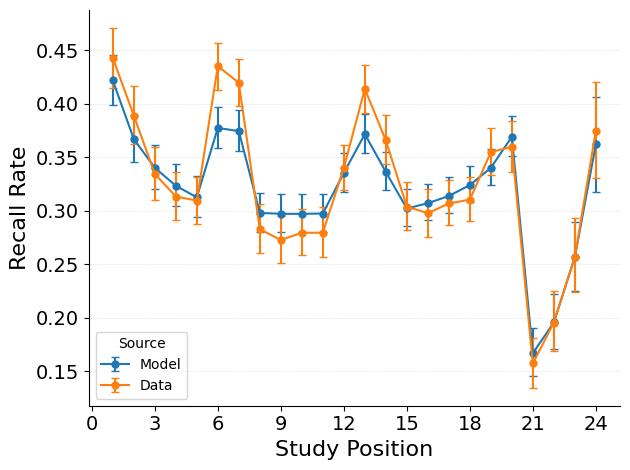

![](projects/repfr/results/figures/fitting/Lohnas2025_FullPositionalCMRNoStop_rerun_best_of_1_crp.png)
plot_crp


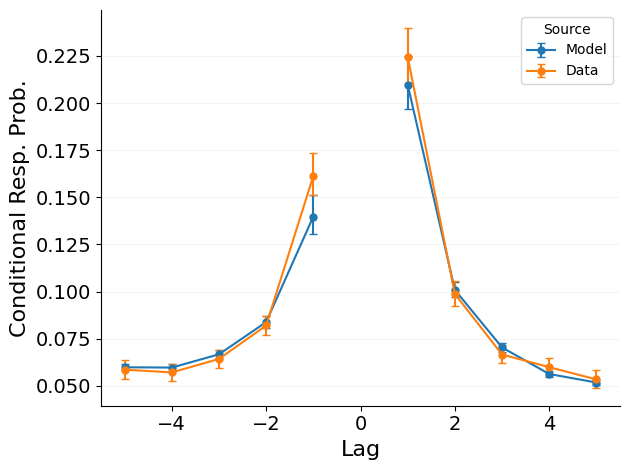

![](projects/repfr/results/figures/fitting/Lohnas2025_FullPositionalCMRNoStop_rerun_best_of_1_pnr.png)
plot_pnr


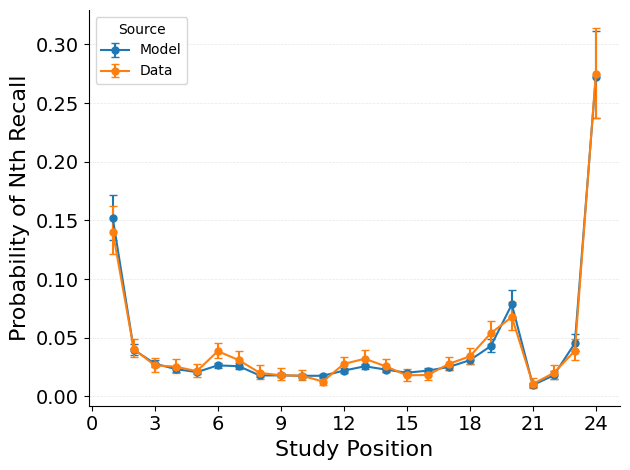

In [9]:
# generate figures comparing model and data
for analysis_cfg in comparison_analyses:
    analysis_fn = analysis_cfg['target']
    trial_queries = _resolve_trial_queries(analysis_cfg, trial_query)
    trial_query_labels = _resolve_trial_query_labels(analysis_cfg, trial_queries)

    for query_index, (query, query_label) in enumerate(zip(trial_queries, trial_query_labels)):
        figure_suffix = analysis_cfg['figure_suffix']
        if len(trial_queries) > 1:
            query_suffix = _format_query_suffix(query_label, query_index)
            figure_suffix = f"{figure_suffix}_{query_suffix}"
        figure_str = f"{data_tag}_{model_name}_{run_tag}_{figure_suffix}.png"
        figure_path = os.path.join(product_dirs["figures"], figure_str)
        print(f"![]({figure_path})")

        if os.path.exists(figure_path) and not redo_figures:
            display(Image(filename=figure_path))
            continue

        if analysis_cfg.get('color_cycle') is None:
            color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
        else:
            color_cycle = analysis_cfg['color_cycle'].copy()

        trial_mask = generate_trial_mask(data, query)
        sim_trial_mask = generate_trial_mask(sim, query)

        base_kwargs = {
            "datasets": [sim, data],
            "trial_masks": [np.array(sim_trial_mask), np.array(trial_mask)],
            "color_cycle": color_cycle,
            "labels": list(analysis_cfg['labels']),
            "contrast_name": analysis_cfg['contrast_name'],
            "axis": None,
        }
        base_kwargs |= analysis_cfg['kwargs']

        signature = inspect.signature(analysis_fn)
        print(analysis_fn.__name__)
        filtered_kwargs = {
            name: value
            for name, value in base_kwargs.items()
            if name in signature.parameters
        }

        axis = analysis_fn(**filtered_kwargs)

        if analysis_cfg['ylim'] is not None:
            axis.set_ylim(analysis_cfg['ylim'])
        plt.tight_layout()
        plt.savefig(figure_path, bbox_inches="tight", dpi=600)
        plt.show()
